In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

***Filter for Germany Data Analyst roles***



In [2]:
df_DA_Germany = df[(df['job_country'] == "Germany") & (df['job_title_short'] == 'Data Analyst')]

In [18]:
mask = df['job_location'] == 'Germany'
df = df.drop(df[mask].index)


In [19]:
df_DA_Germany = df[(df['job_country'] == "Germany") & (df['job_title_short'] == 'Data Analyst')]

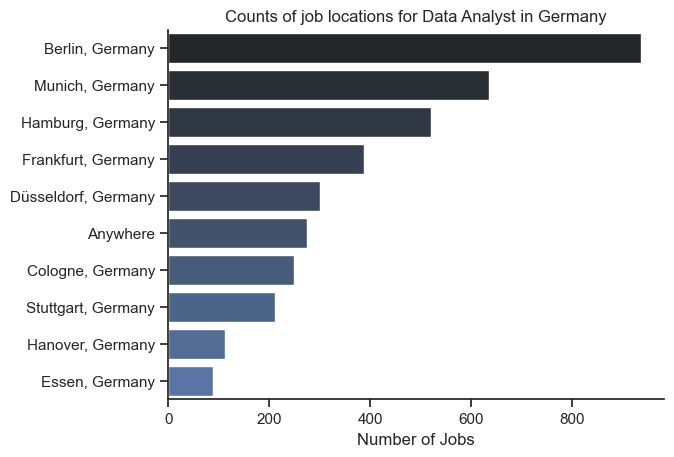

In [21]:
df_plot = (
    df_DA_Germany['job_location']
    .value_counts()
    .head(10)
    .rename_axis('job_location')
    .reset_index(name='count')
)

import seaborn as sns
sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot,
    x='count',
    y='job_location',
    hue='job_location',
    palette='dark:b',
    legend=False
)
sns.despine()
plt.title('Counts of job locations for Data Analyst in Germany')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


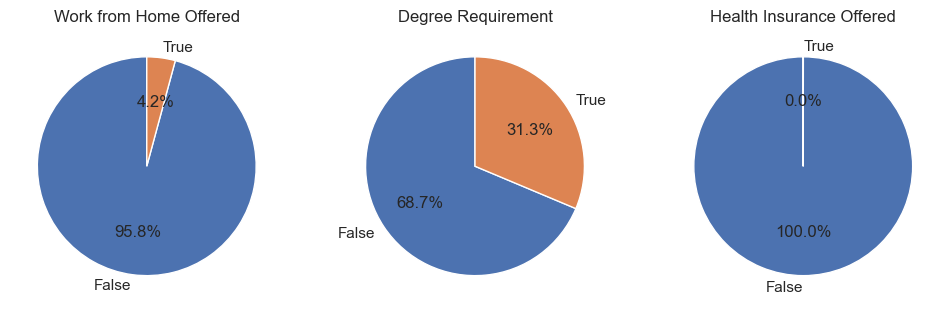

In [22]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_Germany[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

# plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.show()

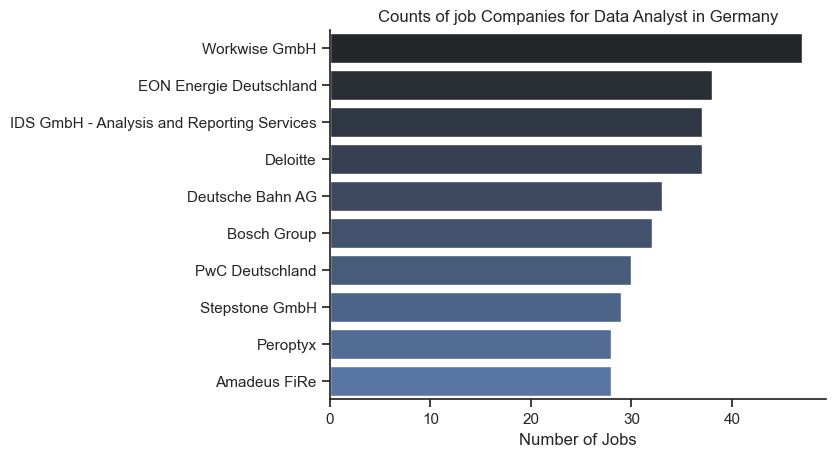

In [25]:
df_plot = (
    df_DA_Germany['company_name']
    .value_counts()
    .head(10)
    .rename_axis('company_name')
    .reset_index(name='count')
)

import seaborn as sns
sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot,
    x='count',
    y='company_name',
    hue='company_name',
    palette='dark:b',
    legend=False
)
sns.despine()
plt.title('Counts of job Companies for Data Analyst in Germany')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()